In [1]:
%load_ext autoreload
%autoreload 2

# Four-week sales forecast

I aggregate sales across all stores and products and explore related factors.
I compare four models in two scenarios over the final 28 days.

In [2]:
import json
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from prophet import Prophet
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from forecast_v3.data import load_sales_data

pd.set_option("display.max_columns", None)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sales = load_sales_data(project_root / "data/raw/demand_forecasting.csv")
print(f"{len(sales):,} source records.")
print("Source data")
display(sales.head())

76,000 source records.
Source data


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Data types

I store identifiers and repeated labels as categories.
I convert promotion and epidemic flags to booleans.

In [3]:
sales = sales.astype({
    "Store ID": "category",
    "Product ID": "category",
    "Category": "category",
    "Region": "category",
    "Weather Condition": "category",
    "Seasonality": "category",
    "Promotion": "bool",
    "Epidemic": "bool",
})
print("Data types")
display(sales.dtypes.to_frame(name="Data type"))

Data types


,Data type
Date,datetime64[us]
Store ID,category
Product ID,category
Category,category
Region,category
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


I store `Date` as a date. I keep sales and discounts numeric
because I use them in calculations.

## How many units were sold each day?

Each row describes one product at one store on one day. For each day,
I sum sales (`Units Sold`) and demand (`Demand`) and average prices
and discounts. The mean of `Promotion` is the share of rows with a promotion.
I count weather once per store per day to find the share of stores with each weather type.

In [4]:
daily = sales.groupby("Date").agg(
    units=("Units Sold", "sum"),
    demand=("Demand", "sum"),
    epidemic=("Epidemic", "max"),
    promotion=("Promotion", "mean"),
    discount=("Discount", "mean"),
    price=("Price", "mean"),
    competitor_price=("Competitor Pricing", "mean"),
)
store_weather = sales[["Date", "Store ID", "Weather Condition"]].drop_duplicates(
    ["Date", "Store ID"]
)
weather_shares = pd.crosstab(
    store_weather["Date"], store_weather["Weather Condition"], normalize="index"
).add_prefix("weather_")
daily = daily.join(weather_shares).sort_index()
print("Daily sales")
display(daily.head())
print(f"{len(daily)} days, {daily['units'].sum():,} units in total.")

Daily sales


,units,demand,epidemic,promotion,discount,price,competitor_price,weather_Cloudy,weather_Rainy,weather_Snowy,weather_Sunny
Date,,,,,,,,,,,
2022-01-01,8601,10060,False,0.15,6.45,68.6690,70.8500,0.2,0.0,0.6,0.2
2022-01-02,7684,10814,False,0.20,7.35,70.3806,72.4986,0.4,0.0,0.4,0.2
2022-01-03,5965,11317,False,0.35,9.15,69.7910,72.1262,0.4,0.0,0.4,0.2
2022-01-04,7859,11469,False,0.45,10.30,69.8443,72.0545,0.4,0.0,0.4,0.2
2022-01-05,9621,11724,False,0.70,14.35,66.8190,68.6097,0.2,0.0,0.6,0.2


760 days, 6,750,876 units in total.


In [5]:
daily_path = project_root / "data/processed/daily_sales.csv"
daily_path.parent.mkdir(parents=True, exist_ok=True)
daily.reset_index().to_csv(daily_path, index=False, date_format="%Y-%m-%d")
print(f"Saved: {daily_path.relative_to(project_root)}")

Saved: data/processed/daily_sales.csv


## Which factors are associated with sales?

## Epidemic

I compare mean daily sales during periods with and without an epidemic.

Sales by epidemic status


,count,mean
epidemic,,
False,608,9581.92
True,152,6085.97


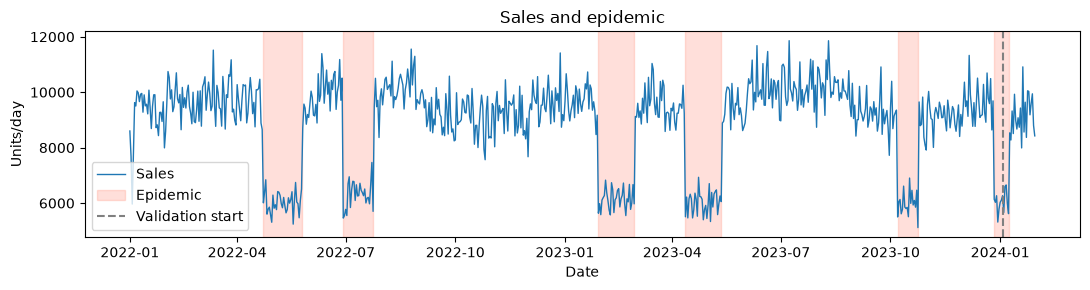

Sales decline during an epidemic: 36.48%


In [6]:
epidemic_summary = daily.groupby("epidemic")["units"].agg(["count", "mean"])
print("Sales by epidemic status")
display(epidemic_summary.round(2))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily.index, daily["units"], linewidth=1, label="Sales")
ax.fill_between(
    daily.index, 0, 1, where=daily["epidemic"],
    transform=ax.get_xaxis_transform(), alpha=0.2, color="tomato", label="Epidemic",
)
ax.axvline(daily.index[-28], color="grey", linestyle="--", label="Validation start")
ax.set(title="Sales and epidemic", xlabel="Date", ylabel="Units/day")
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)

print(f"Sales decline during an epidemic: {1 - (epidemic_summary.iloc[1]["mean"]/epidemic_summary.iloc[0]["mean"]):.2%}")

### How long do epidemics last?

I define an episode as consecutive days with `epidemic=True`.

In [7]:
episode_number = (daily["epidemic"] & ~daily["epidemic"].shift(fill_value=False)).cumsum()
epidemic_days = daily.loc[daily["epidemic"]].reset_index().assign(
    episode=episode_number.loc[daily["epidemic"]].to_numpy()
)
episodes = epidemic_days.groupby("episode").agg(
    start=("Date", "min"), end=("Date", "max"), days=("Date", "size")
)
print("Epidemic episodes")
display(episodes.rename(columns={"start": "Start", "end": "End", "days": "Days"}))
print(
    f"{len(episodes)} episodes, {episodes['days'].sum()} days in total. "
    f"Mean: {episodes['days'].mean():.1f} days; median: {episodes['days'].median():.1f} days."
)

Epidemic episodes


,Start,End,Days
episode,,,
1,2022-04-23,2022-05-25,33
2,2022-06-29,2022-07-24,26
3,2023-01-29,2023-02-28,31
4,2023-04-12,2023-05-12,31
5,2023-10-07,2023-10-24,18
6,2023-12-27,2024-01-08,13


6 episodes, 152 days in total. Mean: 25.3 days; median: 28.5 days.


The first four episodes lasted 26–33 days; the last two lasted 18 and 13 days.
Six episodes are not enough for me to conclude that epidemics are getting shorter.
The last episode lasted 13 days, but only its first 7 days were known on January 2.
I use only information available before validation to make the forecast.

## Demand, prices, promotions, discounts and weather

I calculate correlations between daily variables, including the shares of four
weather types. I explore the full dataset, including the validation period.

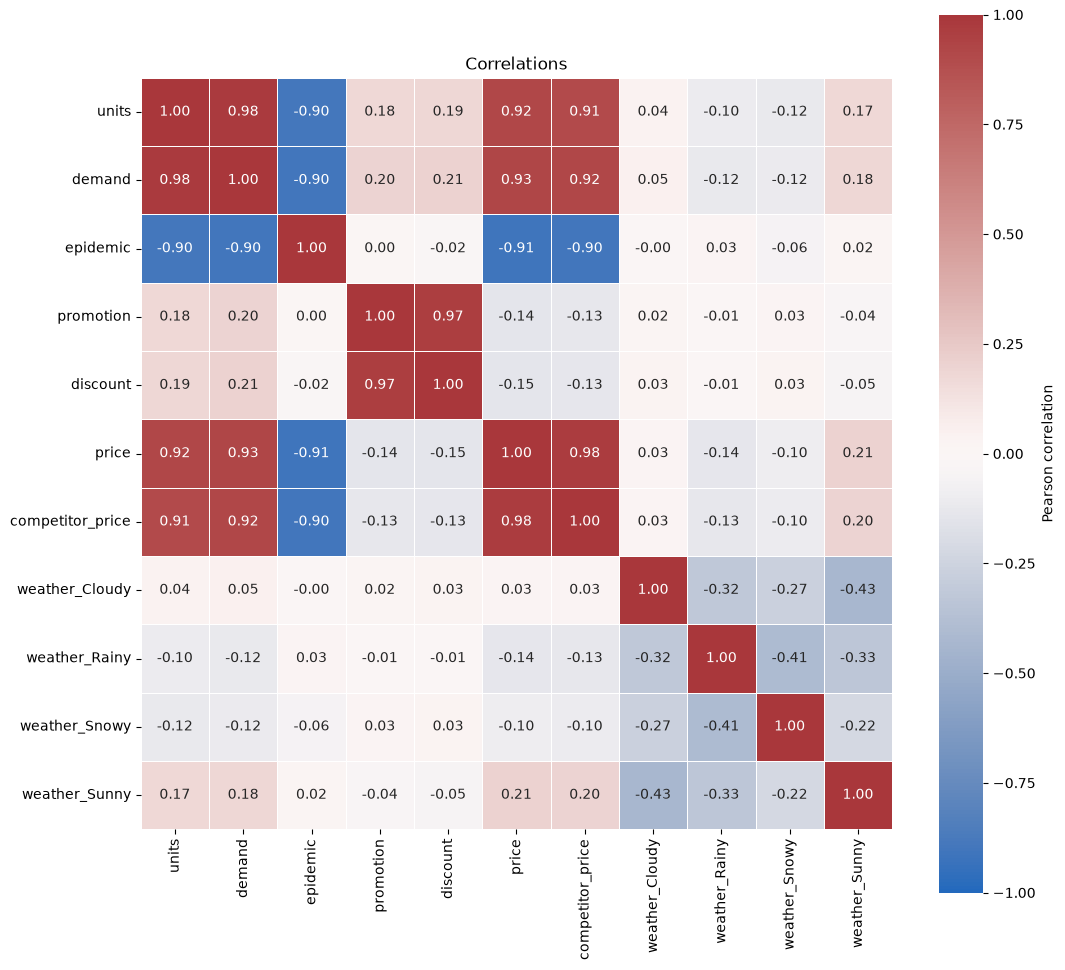

In [8]:
correlations = daily.corr()

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    correlations, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0,
    cmap="vlag", square=True, linewidths=0.5, ax=ax,
    cbar_kws={"label": "Pearson correlation"},
)
ax.set_title("Correlations")
fig.tight_layout()
display(fig)
plt.close(fig)

I observe a strong association between demand and sales (r=0.98). I use only
historical `Demand` in the models because its future values are unknown when forecasting.

Sales correlate negatively with the epidemic flag (r=−0.90) and positively with price (r=0.92).
Price is also associated with the epidemic flag (r=−0.91), so I do not attribute higher sales
to higher prices alone. Own and competitor prices have r=0.98; promotion and discount have r=0.97.
Weather has weak correlations with sales, ranging from −0.12 to 0.17.

## Calendar

I compare mean daily sales by month and weekday, separately for periods
with and without an epidemic. The monthly table and chart cover 2022–2023.
I show four lines: two epidemic states for each year.

In [9]:
calendar = daily.assign(
    year=daily.index.year, month=daily.index.month, weekday=daily.index.dayofweek
)
monthly_calendar = calendar.loc[calendar["year"].isin([2022, 2023])]
monthly_sales = monthly_calendar.groupby(["epidemic", "month"])["units"].mean().unstack(0)
print("Monthly sales")
display(monthly_sales.round(0))

Monthly sales


epidemic,False,True
month,,
1,9404.0,5733.0
2,9682.0,6187.0
3,9681.0,NaN
4,9590.0,5945.0
5,9363.0,6065.0
6,10083.0,5504.0
7,10023.0,6362.0
8,10203.0,NaN
9,9219.0,NaN


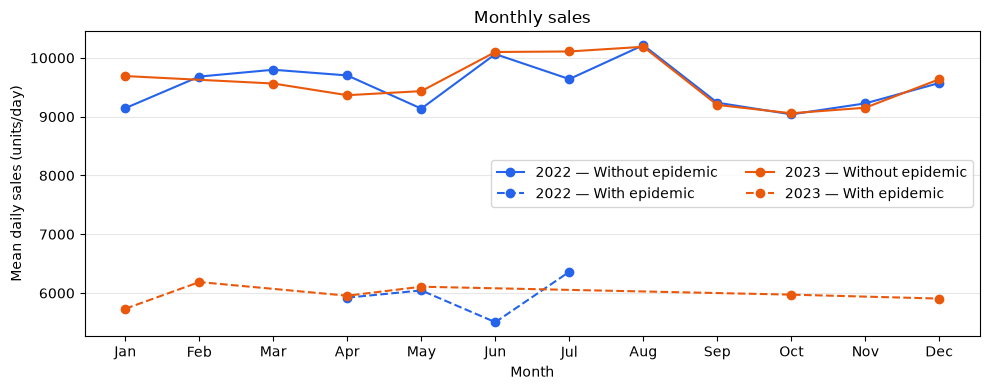

In [10]:
monthly_by_group = (
    monthly_calendar
    .groupby(["year", "epidemic", "month"])["units"]
    .mean()
)
fig, ax = plt.subplots(figsize=(10, 4))
for year, color in ((2022, "#2563eb"), (2023, "#ea580c")):
    for epidemic, style in ((False, "-"), (True, "--")):
        monthly_values = monthly_by_group.loc[(year, epidemic)]
        label = f"{year} — {'With epidemic' if epidemic else 'Without epidemic'}"
        ax.plot(monthly_values.index, monthly_values, marker="o", color=color, linestyle=style, label=label)
ax.set_xticks(range(1, 13), [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
])
ax.set(title="Monthly sales", xlabel="Month", ylabel="Mean daily sales (units/day)")
ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
display(fig)
plt.close(fig)

In both years, I observe the highest mean sales without an epidemic in August.
I see a decline in sales around October.

### Weekday

I compare daily means because the number of observations differs by weekday.
I also show the number of days in each group.

In [11]:
weekday_stats = calendar.groupby(["weekday", "epidemic"])["units"].agg(["mean", "size"])
weekday_mean = weekday_stats["mean"].unstack("epidemic")
weekday_days = weekday_stats["size"].unstack("epidemic")
weekday_table = pd.DataFrame({
    "Without epidemic (units/day)": weekday_mean[False],
    "With epidemic (units/day)": weekday_mean[True],
    "Days without epidemic": weekday_days[False],
    "Days with epidemic": weekday_days[True],
}).rename(index=dict(enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]))).rename_axis(
    "Weekday"
)
print("Weekdays")
display(weekday_table.round(0))

Weekdays


,Without epidemic (units/day),With epidemic (units/day),Days without epidemic,Days with epidemic
Weekday,,,,
Mon,9460.0,6127.0,87,22
Tue,9524.0,5980.0,88,21
Wed,9719.0,5968.0,86,22
Thu,9550.0,6143.0,87,21
Fri,9581.0,6172.0,87,21
Sat,9616.0,6048.0,87,22
Sun,9626.0,6162.0,86,23


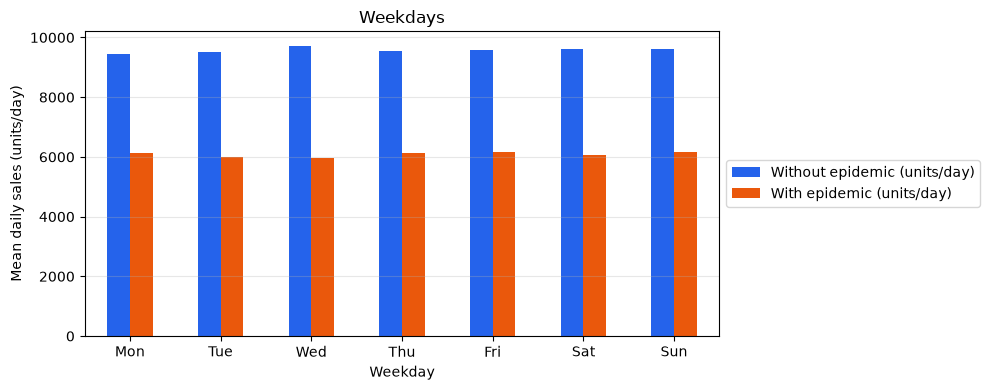

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
weekday_table[["Without epidemic (units/day)", "With epidemic (units/day)"]].plot.bar(
    ax=ax, color=["#2563eb", "#ea580c"], rot=0,
)
ax.set(title="Weekdays", xlabel="Weekday", ylabel="Mean daily sales (units/day)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="", loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()
display(fig)
plt.close(fig)

Without an epidemic, sales are highest on Wednesday (9,719 units/day)
and lowest on Monday (9,460), a difference of about 3%.
During an epidemic, Friday has the highest mean (6,172),
but differences between weekdays are also small. The difference
between days with and without an epidemic is much larger.

## Two scenarios

I compare four model families. I tune LightGBM parameters in a loop
and keep the previous settings for the other models.
I train the models on data from before validation.

| Scenario | Information available for forecasting |
|---|---|
| History only | History through January 2 and the calendar for future dates |
| Known prices and promotions | The same information, plus future prices, promotions and discounts |

In the second scenario, I treat actual prices, promotions and discounts
as a perfect company plan. Future sales, demand and epidemic status remain unknown.
I use the same validation window to choose model variants and parameters.
I therefore treat the results as a historical evaluation, rather than an independent test.

## Training and validation

I hold out the final 28 days for validation, leaving 732 days for training.
After skipping the first 55 days needed to calculate lags and rolling means,
I train models with historical features on 677 days.

In [13]:
train = daily[["units", "epidemic", "price", "demand", "promotion", "discount"]].iloc[:-28]
validation = daily[["units"]].iloc[-28:]
print("Data split")
display(pd.DataFrame({
    "From": [train.index[0], validation.index[0]],
    "To": [train.index[-1], validation.index[-1]],
    "Days": [len(train), len(validation)],
}, index=["Training", "Validation"]))

Data split


,From,To,Days
Training,2022-01-01,2024-01-02,732
Validation,2024-01-03,2024-01-30,28


## Metrics and chart

For each model, I calculate MAE, RMSE, MAPE and bias against validation sales.
I show the metrics directly below the chart.
I interpret them as follows:

- **MAE**: mean absolute error in units/day.
- **RMSE**: error in units/day, giving more weight to large errors.
- **MAPE**: mean absolute percentage error.
- **Bias**: percentage error in total sales; positive means overestimation, negative means underestimation.

In [14]:
def forecast_metrics(actual: pd.Series, prediction: pd.Series) -> dict[str, float]:
    """Calculate forecast errors over the full validation window."""
    error = prediction.to_numpy() - actual.to_numpy()
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "MAPE (%)": float(100 * np.mean(np.abs(error / actual.to_numpy()))),
        "Bias (%)": float(100 * error.sum() / actual.sum()),
    }

In [15]:
def show_forecast(
    actual: pd.Series,
    prediction: pd.Series,
    title: str,
    baseline: pd.Series | None = None,
    without_ar: pd.Series | None = None,
) -> None:
    """Show the forecast with metrics directly below the chart."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(actual, label="Sales", color="#475569")
    results = {}
    if baseline is not None:
        ax.plot(baseline, label="Baseline", color="#d97706", linestyle="--")
        results["Baseline"] = forecast_metrics(actual, baseline)
    if without_ar is not None:
        ax.plot(without_ar, label="Lasso without AR", color="#be185d", linestyle=":")
        results["Lasso without AR"] = forecast_metrics(actual, without_ar)
    ax.plot(prediction, label="Forecast", color="#059669")
    ax.set(title=title, xlabel="Date", ylabel="Units/day")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    display(fig)
    plt.close(fig)
    results[title] = forecast_metrics(actual, prediction)
    display(pd.DataFrame.from_dict(results, orient="index").round(2))

## Features

I encode each day's position in a cycle using sine/cosine pairs. I include
periods of roughly one year and half a year, plus 7, 14 and 28 days. For LightGBM
without a plan, I omit short cycles, which increased MAE in earlier runs on this window.

In [16]:
calendar_columns = {}
for harmonic in (1, 2):
    angle = 2 * np.pi * harmonic * daily.index.dayofyear.to_numpy() / 365.25
    calendar_columns[f"sin{harmonic}"] = np.sin(angle)
    calendar_columns[f"cos{harmonic}"] = np.cos(angle)
elapsed_days = (daily.index - daily.index[0]).days.to_numpy()
short_cycles = []
for period in (7, 14, 28):
    angle = 2 * np.pi * (elapsed_days % period) / period
    calendar_columns[f"sin_{period}d"] = np.sin(angle)
    calendar_columns[f"cos_{period}d"] = np.cos(angle)
    short_cycles.extend([f"sin_{period}d", f"cos_{period}d"])

I encode Monday through Saturday and three seasons as 0/1 flags.
I use Sunday and winter as reference categories, represented by zeros
in their respective groups of flags.

In [17]:
for weekday in range(6):
    calendar_columns[f"dow{weekday}"] = (daily.index.dayofweek == weekday).astype(int)
month_day = daily.index.month * 100 + daily.index.day
for label, start, end in (("autumn", 923, 1221), ("spring", 320, 621), ("summer", 621, 923)):
    calendar_columns[f"season_{label}"] = ((month_day >= start) & (month_day < end)).astype(int)
calendar_features = pd.DataFrame(calendar_columns, index=daily.index)

I use sales, epidemic status, price, demand, promotion and discount from 28 days earlier.
I add 28-day means of sales and epidemic status, also lagged by 28 days.
This makes all historical values available before validation starts.
I derive calendar features from dates. I skip the first `28 + 28 − 1 = 55` days
so that every training observation has enough history for these features.

I interpret feature names as follows:

| Name component | Meaning |
|---|---|
| `lag28` | Value 28 days before the forecast date |
| `mean28_lag28` | Mean over 28 days ending 28 days before the forecast date |
| `plan` | Known prices, promotions and discounts; `lag7` is the value 7 days earlier, `mean7` is a 7-day mean |

In [18]:
history = train.reindex(daily.index)
history = history.astype({"epidemic": float})
lag_28 = history.shift(28).add_suffix("_lag28")
shifted_history = history[["units", "epidemic"]].shift(28)
mean_28 = shifted_history.rolling(28).mean().add_suffix("_mean28_lag28")
lag_columns = [*lag_28.columns, *mean_28.columns]
all_features = calendar_features.join([lag_28, mean_28])
history_start = 28 + 28 - 1
training_features = all_features.loc[train.index].iloc[history_start:]
future_features = all_features.loc[validation.index]
target = train.loc[training_features.index, "units"]

## Baseline

For every forecast day, I use mean sales from the final 28 days of training.
I use this as the baseline in both scenarios.

Baseline inputs


['units']

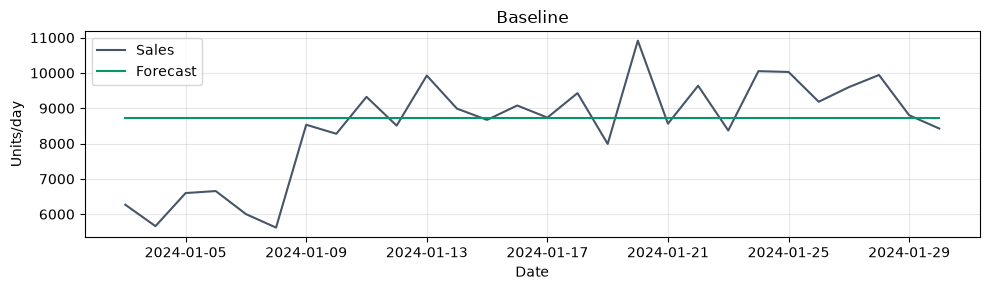

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.5,1417.94,14.38,2.66


In [19]:
print("Baseline inputs")
display(train[["units"]].columns.tolist())
baseline_prediction = pd.Series(train["units"].tail(28).mean(), index=validation.index)
show_forecast(validation["units"], baseline_prediction, "Baseline")

## 1. History only

I forecast 28 days using information available on January 2, 2024.
I use history and the calendar. Future sales and epidemic status
remain unknown at the time of forecasting.

In [20]:
history_forecasts = {"mean28": baseline_prediction}

### Lasso + AR(1)

I use calendar cycles and historical data. I fit the scaler on training data.
The L1 penalty shrinks coefficients and sets some of them to zero.

In [21]:
print("Lasso features")
display(training_features.columns.tolist())
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=25, max_iter=50_000))
lasso_model.fit(training_features, target)
lasso_values = lasso_model.predict(future_features)
lasso_prediction = pd.Series(lasso_values, index=validation.index)

Lasso features


['sin1',
 'cos1',
 'sin2',
 'cos2',
 'sin_7d',
 'cos_7d',
 'sin_14d',
 'cos_14d',
 'sin_28d',
 'cos_28d',
 'dow0',
 'dow1',
 'dow2',
 'dow3',
 'dow4',
 'dow5',
 'season_autumn',
 'season_spring',
 'season_summer',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28']

AR(1) is autoregression with a one-day lag. I fit it to Lasso residuals
(`sales − fitted value`) using this formula:
`residual today = intercept + coefficient × residual yesterday`.
I add the predicted residual to the Lasso forecast to correct it.

In [22]:
lasso_fitted = lasso_model.predict(training_features)
lasso_residuals = target - lasso_fitted
ar_training = pd.DataFrame({
    "residual_lag1": lasso_residuals.shift(1), "residual": lasso_residuals,
}).dropna()
print("AR(1) features")
display(ar_training[["residual_lag1"]].columns.tolist())
ar_model = LinearRegression()
ar_model.fit(ar_training[["residual_lag1"]], ar_training["residual"]);

AR(1) features


['residual_lag1']

I start with the final training residual from January 2. For subsequent days,
I use the previously predicted residual. I calculate the full 28-day correction
without using actual validation sales.

AR(1) parameters


,Value
Intercept,-3.525
Lag1,0.798
Last residual,-2586.836


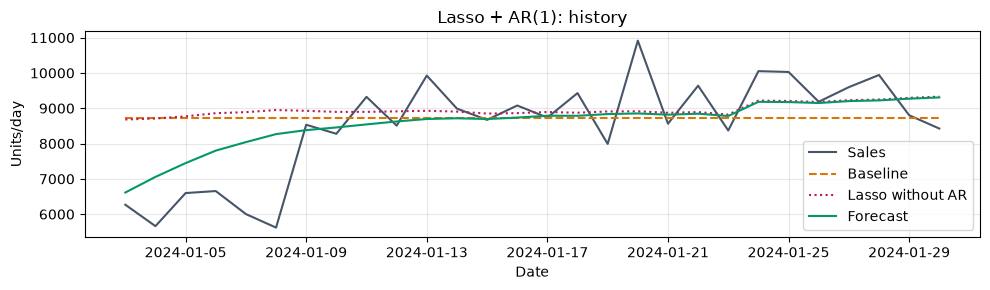

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.50,1417.94,14.38,2.66
Lasso without AR,1022.68,1403.66,14.31,5.53
Lasso + AR(1): history,742.99,982.72,9.72,1.06


In [23]:
ar_intercept = float(ar_model.intercept_)
ar_coefficient = float(ar_model.coef_[0])
last_residual = float(lasso_residuals.iloc[-1])
print("AR(1) parameters")
display(pd.Series({
    "Intercept": ar_intercept, "Lag1": ar_coefficient, "Last residual": last_residual,
}).to_frame("Value").round(3))
ar_values = []
for date in validation.index:
    last_residual = ar_intercept + ar_coefficient * last_residual
    ar_values.append(last_residual)
ar_correction = pd.Series(ar_values, index=validation.index)
history_forecasts["lasso"] = (lasso_prediction + ar_correction).clip(lower=0)
show_forecast(
    validation["units"], history_forecasts["lasso"], "Lasso + AR(1): history",
    baseline_prediction, without_ar=lasso_prediction.clip(lower=0),
)

I show nonzero Lasso coefficients for standardized features.
One unit of a standardized feature equals its standard deviation in training.

In [24]:
lasso_coefficients = pd.Series(lasso_model.named_steps["lasso"].coef_, index=training_features.columns)
print("Retained Lasso features")
display(lasso_coefficients[lasso_coefficients.ne(0)].rename("Coefficient").to_frame().round(2))

Retained Lasso features


,Coefficient
sin1,-436.48
cos1,41.12
sin2,378.33
cos2,81.59
sin_14d,-32.86
cos_14d,-25.48
sin_28d,-28.01
cos_28d,-56.54
dow0,-2.34
season_spring,56.34


The correction reduces MAE from 1,022.68 to 742.99 units/day.
The effect of the last residual gradually fades. The correction does not predict the date of the sales jump.

### LightGBM

For each parameter combination, I train one model on history and calendar features without short cycles.
I pass it 28 feature rows to forecast the full validation window.
I use `ParameterGrid` to try every parameter combination.
I select the model with the lowest validation MAE and show the top 10 results.
Using the same window for parameter selection and evaluation may make the result too optimistic.

In [25]:
lgbm_training_features = training_features.drop(columns=short_cycles)
lgbm_future = future_features.drop(columns=short_cycles)
LIGHTGBM_FIXED = {
    "objective": "regression", "random_state": 42, "n_jobs": 1,
    "verbosity": -1, "deterministic": True, "force_col_wise": True,
}
LIGHTGBM_GRID = {
    "n_estimators": (100, 200, 400, 800),
    "learning_rate": (0.025, 0.05, 0.1, 0.2),
    "num_leaves": (7, 15, 31, 62),
    "min_child_samples": (10, 20, 40, 80),
    "reg_lambda": (0.0, 1.0, 5.0, 10.0),
}
print("Parameter grid")
display(pd.Series(LIGHTGBM_GRID, name="Values").to_frame())
print(f"Combinations per scenario: {len(ParameterGrid(LIGHTGBM_GRID))}")

Parameter grid


,Values
n_estimators,"(100, 200, 400, 800)"
learning_rate,"(0.025, 0.05, 0.1, 0.2)"
num_leaves,"(7, 15, 31, 62)"
min_child_samples,"(10, 20, 40, 80)"
reg_lambda,"(0.0, 1.0, 5.0, 10.0)"


Combinations per scenario: 1024


In [26]:
print("LightGBM features")
display(lgbm_training_features.columns.tolist())
lgbm_trials = []
lgbm_best_mae = np.inf
for params in ParameterGrid(LIGHTGBM_GRID):
    candidate = LGBMRegressor(**LIGHTGBM_FIXED, **params)
    candidate.fit(lgbm_training_features, target)
    values = np.maximum(candidate.predict(lgbm_future), 0)
    prediction = pd.Series(values, index=validation.index)
    errors = forecast_metrics(validation["units"], prediction)
    lgbm_trials.append({**params, **errors})
    if errors["MAE"] < lgbm_best_mae:
        lgbm_best_mae = errors["MAE"]
        lgbm_best_params = params
        lgbm_model = candidate
        history_forecasts["lightgbm"] = prediction

LightGBM features


['sin1',
 'cos1',
 'sin2',
 'cos2',
 'dow0',
 'dow1',
 'dow2',
 'dow3',
 'dow4',
 'dow5',
 'season_autumn',
 'season_spring',
 'season_summer',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28']

Tuning results


,learning_rate,min_child_samples,n_estimators,num_leaves,reg_lambda,MAE,RMSE,MAPE (%),Bias (%)
0,0.025,80,100,7,10.0,1074.16,1515.71,15.28,7.12
1,0.025,80,100,15,10.0,1074.16,1515.71,15.28,7.12
2,0.025,80,100,31,10.0,1074.16,1515.71,15.28,7.12
3,0.025,80,100,62,10.0,1074.16,1515.71,15.28,7.12
4,0.050,80,100,7,10.0,1079.00,1551.19,15.48,8.50
5,0.050,80,100,15,10.0,1079.00,1551.19,15.48,8.50
6,0.050,80,100,31,10.0,1079.00,1551.19,15.48,8.50
7,0.050,80,100,62,10.0,1079.00,1551.19,15.48,8.50
8,0.025,80,100,7,5.0,1079.74,1537.77,15.45,7.87
9,0.025,80,100,15,5.0,1079.74,1537.77,15.45,7.87


Selected parameters


{'learning_rate': 0.025,
 'min_child_samples': 80,
 'n_estimators': 100,
 'num_leaves': 7,
 'reg_lambda': 10.0}

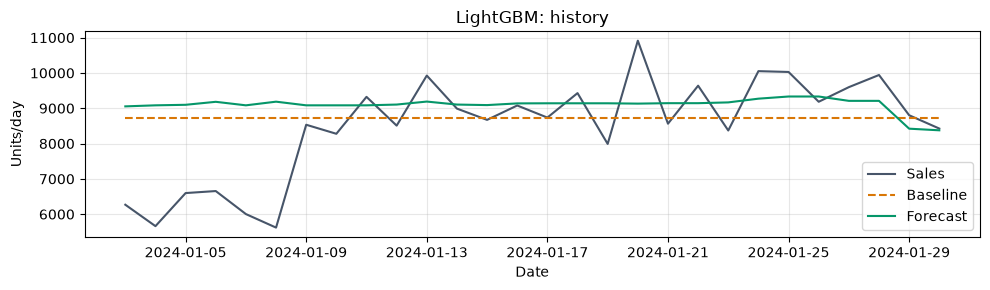

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.50,1417.94,14.38,2.66
LightGBM: history,1074.16,1515.71,15.28,7.12


In [27]:
lgbm_results = pd.DataFrame(lgbm_trials).sort_values("MAE", kind="stable").reset_index(drop=True)
print("Tuning results")
display(lgbm_results.head(10).round({"MAE": 2, "RMSE": 2, "MAPE (%)": 2, "Bias (%)": 2}))
print("Selected parameters")
display(lgbm_best_params)
show_forecast(validation["units"], history_forecasts["lightgbm"], "LightGBM: history", baseline_prediction)

In [28]:
lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=lgbm_training_features.columns)
print("Features used by LightGBM")
display(lgbm_importance[lgbm_importance.gt(0)].sort_values(ascending=False).rename("Splits").to_frame())

Features used by LightGBM


,Splits
sin1,160
cos1,115
units_mean28_lag28,92
sin2,84
cos2,44
price_lag28,21
demand_lag28,14
epidemic_mean28_lag28,6
units_lag28,2


### Prophet

I fit a trend and built-in weekly seasonality. I add historical features
and 14- and 28-day cycles.
I disable yearly seasonality.
I pass dates in `ds` and sales in `y` as the training target.

Prophet features


['ds',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28',
 'sin_14d',
 'cos_14d',
 'sin_28d',
 'cos_28d']

20:08:12 - cmdstanpy - INFO - Chain [1] start processing


20:08:13 - cmdstanpy - INFO - Chain [1] done processing


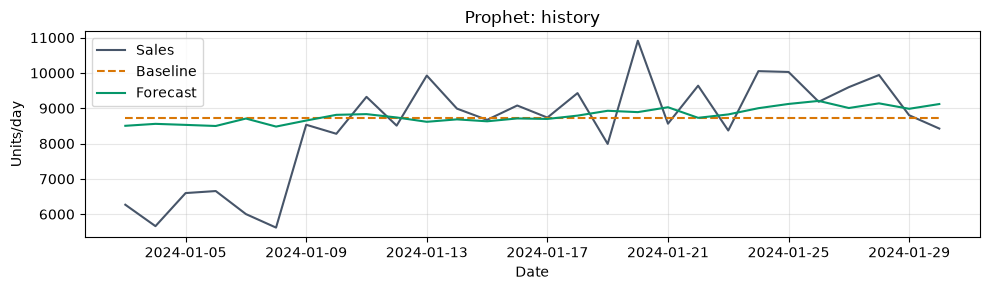

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.50,1417.94,14.38,2.66
Prophet: history,985.41,1317.89,13.53,3.64


In [29]:
prophet_columns = [*lag_columns, "sin_14d", "cos_14d", "sin_28d", "cos_28d"]
prophet_training = train.loc[training_features.index, ["units"]]
prophet_training = prophet_training.join(training_features[prophet_columns])
prophet_training = prophet_training.reset_index().rename(columns={"Date": "ds", "units": "y"})
prophet_future = future_features[prophet_columns].reset_index().rename(columns={"Date": "ds"})
print("Prophet features")
display(prophet_training.columns.drop("y").tolist())
prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
for column in prophet_columns:
    prophet_model.add_regressor(column)
prophet_model.fit(prophet_training)
prophet_result = prophet_model.predict(prophet_future)
prophet_values = np.maximum(prophet_result["yhat"].to_numpy(), 0)
history_forecasts["prophet"] = pd.Series(prophet_values, index=validation.index)
show_forecast(validation["units"], history_forecasts["prophet"], "Prophet: history", baseline_prediction)

Lasso + AR(1) has the lowest MAE in this scenario: 742.99 units/day.
After tuning LightGBM, I retain its previous parameters and MAE of 1,074.16 units/day.

## 2. Known prices and promotions

In this scenario, I know mean prices, promotion shares and mean discounts
for the 28 forecast days. I simulate a company plan by taking only these three
variables from validation. I add their 7-day lags and 7-day means, including the forecast day.

**Note: possible data leakage.** If validation prices, promotions and discounts
were not actually known at the time of forecasting, using them leaks future information
and may produce an overly optimistic evaluation. I therefore treat this scenario
as a conditional forecast, valid if the plan is known in advance.

In [30]:
plan_columns = ["price", "promotion", "discount"]
plan_history = pd.concat([train[plan_columns], daily.loc[validation.index, plan_columns]])
plan_features = plan_history.add_suffix("_plan").join([
    plan_history.shift(7).add_suffix("_plan_lag7"),
    plan_history.rolling(7).mean().add_suffix("_plan_mean7"),
])
plan_feature_columns = list(plan_features.columns)
plan_training = training_features.join(plan_features.loc[training_features.index])
plan_future = future_features.join(plan_features.loc[validation.index])
plan_forecasts = {"mean28": baseline_prediction}

### Lasso

I use history, the calendar and the plan. I keep the same L1 penalty.

Lasso features with plan


['sin1',
 'cos1',
 'sin2',
 'cos2',
 'sin_7d',
 'cos_7d',
 'sin_14d',
 'cos_14d',
 'sin_28d',
 'cos_28d',
 'dow0',
 'dow1',
 'dow2',
 'dow3',
 'dow4',
 'dow5',
 'season_autumn',
 'season_spring',
 'season_summer',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28',
 'price_plan',
 'promotion_plan',
 'discount_plan',
 'price_plan_lag7',
 'promotion_plan_lag7',
 'discount_plan_lag7',
 'price_plan_mean7',
 'promotion_plan_mean7',
 'discount_plan_mean7']

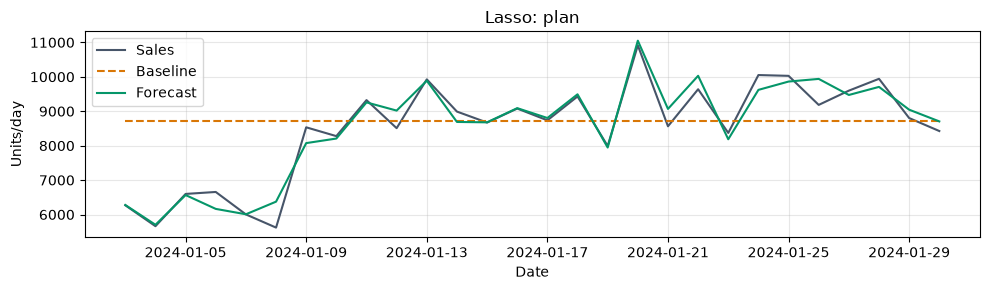

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.5,1417.94,14.38,2.66
Lasso: plan,229.3,318.82,2.80,0.47


In [31]:
print("Lasso features with plan")
display(plan_training.columns.tolist())
plan_lasso = make_pipeline(StandardScaler(), Lasso(alpha=25, max_iter=50_000))
plan_lasso.fit(plan_training, target)
plan_lasso_values = plan_lasso.predict(plan_future)
plan_lasso_values = np.maximum(plan_lasso_values, 0)
plan_forecasts["lasso"] = pd.Series(plan_lasso_values, index=validation.index)
show_forecast(validation["units"], plan_forecasts["lasso"], "Lasso: plan", baseline_prediction)

Here too, I show coefficients for standardized features.

In [32]:
plan_coefficients = pd.Series(plan_lasso.named_steps["lasso"].coef_, index=plan_training.columns)
print("Retained Lasso features")
display(plan_coefficients[plan_coefficients.ne(0)].rename("Coefficient").to_frame().round(2))

Retained Lasso features


,Coefficient
cos1,-38.13
price_plan,1354.19
promotion_plan,33.76
discount_plan,434.90
price_plan_mean7,195.58


### LightGBM

I use historical features, cycles and the plan, including its 7-day lags and means.
I try the same parameter grid. I select the model with the lowest validation MAE
separately for this scenario.

In [33]:
print("LightGBM features with plan")
display(plan_training.columns.tolist())
plan_lgbm_trials = []
plan_lgbm_best_mae = np.inf
for params in ParameterGrid(LIGHTGBM_GRID):
    candidate = LGBMRegressor(**LIGHTGBM_FIXED, **params)
    candidate.fit(plan_training, target)
    values = np.maximum(candidate.predict(plan_future), 0)
    prediction = pd.Series(values, index=validation.index)
    errors = forecast_metrics(validation["units"], prediction)
    plan_lgbm_trials.append({**params, **errors})
    if errors["MAE"] < plan_lgbm_best_mae:
        plan_lgbm_best_mae = errors["MAE"]
        plan_lgbm_best_params = params
        plan_lgbm = candidate
        plan_forecasts["lightgbm"] = prediction

LightGBM features with plan


['sin1',
 'cos1',
 'sin2',
 'cos2',
 'sin_7d',
 'cos_7d',
 'sin_14d',
 'cos_14d',
 'sin_28d',
 'cos_28d',
 'dow0',
 'dow1',
 'dow2',
 'dow3',
 'dow4',
 'dow5',
 'season_autumn',
 'season_spring',
 'season_summer',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28',
 'price_plan',
 'promotion_plan',
 'discount_plan',
 'price_plan_lag7',
 'promotion_plan_lag7',
 'discount_plan_lag7',
 'price_plan_mean7',
 'promotion_plan_mean7',
 'discount_plan_mean7']

Tuning results


,learning_rate,min_child_samples,n_estimators,num_leaves,reg_lambda,MAE,RMSE,MAPE (%),Bias (%)
0,0.20,20,800,15,0.0,251.85,338.40,3.02,0.12
1,0.20,20,400,15,0.0,251.98,338.61,3.02,0.13
2,0.20,20,200,15,0.0,252.59,339.89,3.03,0.17
3,0.20,10,200,7,10.0,252.75,346.85,3.11,0.51
4,0.10,10,200,15,0.0,253.46,339.95,3.15,1.14
5,0.20,20,400,7,10.0,255.43,355.53,3.13,0.30
6,0.20,20,200,7,10.0,255.46,351.15,3.14,0.39
7,0.10,10,400,15,0.0,255.91,341.49,3.18,1.13
8,0.05,10,800,15,0.0,256.35,352.34,3.16,1.06
9,0.20,20,800,7,10.0,256.99,356.22,3.14,0.29


Selected parameters


{'learning_rate': 0.2,
 'min_child_samples': 20,
 'n_estimators': 800,
 'num_leaves': 15,
 'reg_lambda': 0.0}

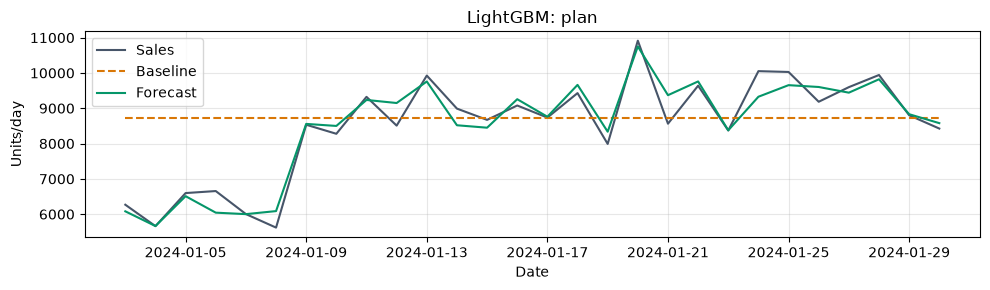

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.50,1417.94,14.38,2.66
LightGBM: plan,251.85,338.40,3.02,0.12


In [34]:
plan_lgbm_results = pd.DataFrame(plan_lgbm_trials).sort_values("MAE", kind="stable").reset_index(drop=True)
print("Tuning results")
display(plan_lgbm_results.head(10).round({"MAE": 2, "RMSE": 2, "MAPE (%)": 2, "Bias (%)": 2}))
print("Selected parameters")
display(plan_lgbm_best_params)
show_forecast(validation["units"], plan_forecasts["lightgbm"], "LightGBM: plan", baseline_prediction)

In [35]:
plan_importance = pd.Series(plan_lgbm.feature_importances_, index=plan_training.columns)
print("Features used by LightGBM")
display(plan_importance[plan_importance.gt(0)].sort_values(ascending=False).rename("Splits").to_frame())

Features used by LightGBM


,Splits
price_plan,861
discount_plan,769
price_lag28,734
discount_plan_lag7,710
price_plan_lag7,676
units_lag28,668
discount_lag28,667
price_plan_mean7,667
discount_plan_mean7,662
demand_lag28,600


### Prophet

I add all plan features to history and the 14/28-day cycles.

Prophet features with plan


['ds',
 'units_lag28',
 'epidemic_lag28',
 'price_lag28',
 'demand_lag28',
 'promotion_lag28',
 'discount_lag28',
 'units_mean28_lag28',
 'epidemic_mean28_lag28',
 'sin_14d',
 'cos_14d',
 'sin_28d',
 'cos_28d',
 'price_plan',
 'promotion_plan',
 'discount_plan',
 'price_plan_lag7',
 'promotion_plan_lag7',
 'discount_plan_lag7',
 'price_plan_mean7',
 'promotion_plan_mean7',
 'discount_plan_mean7']

20:10:27 - cmdstanpy - INFO - Chain [1] start processing


20:10:27 - cmdstanpy - INFO - Chain [1] done processing


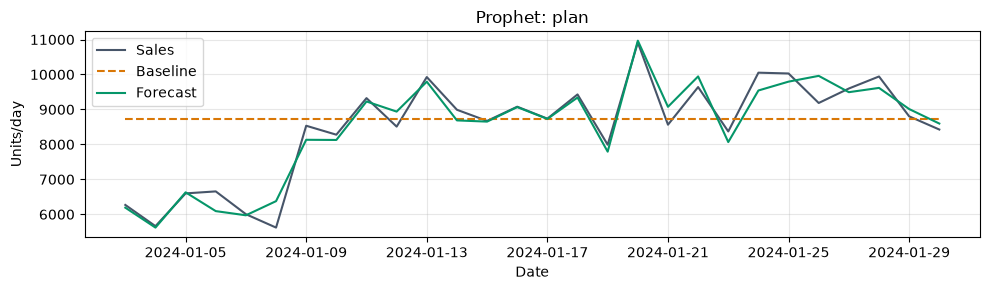

,MAE,RMSE,MAPE (%),Bias (%)
Baseline,1053.50,1417.94,14.38,2.66
Prophet: plan,244.51,326.91,3.00,-0.15


In [36]:
plan_prophet_columns = [*prophet_columns, *plan_feature_columns]
plan_prophet_training = train.loc[training_features.index, ["units"]]
plan_prophet_training = plan_prophet_training.join(plan_training[plan_prophet_columns])
plan_prophet_training = plan_prophet_training.reset_index().rename(columns={"Date": "ds", "units": "y"})
plan_prophet_future = plan_future[plan_prophet_columns].reset_index().rename(columns={"Date": "ds"})
print("Prophet features with plan")
display(plan_prophet_training.columns.drop("y").tolist())
plan_prophet = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
for column in plan_prophet_columns:
    plan_prophet.add_regressor(column)
plan_prophet.fit(plan_prophet_training)
plan_prophet_result = plan_prophet.predict(plan_prophet_future)
plan_prophet_values = np.maximum(plan_prophet_result["yhat"].to_numpy(), 0)
plan_forecasts["prophet"] = pd.Series(plan_prophet_values, index=validation.index)
show_forecast(validation["units"], plan_forecasts["prophet"], "Prophet: plan", baseline_prediction)

With the known plan, Lasso gives me the lowest MAE: 229.30 units/day.
Tuning LightGBM reduced its MAE from 262.29 to 251.85 units/day.
I use actual prices, promotions and discounts here. A company plan prepared
before forecasting could differ from these values.

## Model comparison

I compare models on the same 28 days used to select variants and parameters.
I treat the results as a historical evaluation.

In [37]:
MODEL_NAMES = {
    "mean28": "28-day mean", "lasso": "Lasso",
    "lightgbm": "LightGBM", "prophet": "Prophet",
}
SCENARIO_MODEL_NAMES = {
    "history": {**MODEL_NAMES, "lasso": "Lasso + AR(1)"},
    "known_plan": MODEL_NAMES,
}
SCENARIO_NAMES = {"history": "History only", "known_plan": "Known prices and promotions"}
scenario_forecasts = {"history": history_forecasts, "known_plan": plan_forecasts}

In [38]:
metric_rows = []
comparison_rows = []
for scenario, forecasts in scenario_forecasts.items():
    for model, prediction in forecasts.items():
        errors = forecast_metrics(validation["units"], prediction)
        metric_rows.append({"scenario": scenario, "model": model, **errors})
        comparison_rows.append({
            "Scenario": SCENARIO_NAMES[scenario],
            "Model": SCENARIO_MODEL_NAMES[scenario][model],
            **errors,
        })
metrics = pd.DataFrame(metric_rows)
comparison = pd.DataFrame(comparison_rows).set_index(["Scenario", "Model"])
print("Errors in both scenarios")
display(comparison.round(2))

Errors in both scenarios


MAE     RMSE  MAPE (%)  \
Scenario                    Model                                       
History only                28-day mean    1053.50  1417.94     14.38   
                            Lasso + AR(1)   742.99   982.72      9.72   
                            LightGBM       1074.16  1515.71     15.28   
                            Prophet         985.41  1317.89     13.53   
Known prices and promotions 28-day mean    1053.50  1417.94     14.38   
                            Lasso           229.30   318.82      2.80   
                            LightGBM        251.85   338.40      3.02   
                            Prophet         244.51   326.91      3.00   

                                           Bias (%)  
Scenario                    Model                    
History only                28-day mean        2.66  
                            Lasso + AR(1)      1.06  
                            LightGBM           7.12  
                            Prophet            3.64  
Known prices and promotions 28-day mean        2.66  
                            Lasso              0.47  
                            LightGBM           0.12  
                            Prophet           -0.15

In [39]:
selected_models = {}
for scenario in SCENARIO_NAMES:
    scenario_metrics = metrics.loc[metrics["scenario"].eq(scenario)].set_index("model")
    selected_models[scenario] = scenario_metrics["MAE"].idxmin()

Based on MAE, I select Lasso + AR(1) for History only (742.99 units/day)
and Lasso for the known plan (229.30 units/day). Both outperform
the baseline (1,053.50 units/day). The result with the plan depends
on knowing future prices, promotions and discounts.

In [40]:
prediction_tables = []
for scenario, forecasts in scenario_forecasts.items():
    scenario_predictions = pd.DataFrame(forecasts, index=validation.index)
    scenario_predictions = scenario_predictions.assign(actual=validation["units"], scenario=scenario)
    prediction_tables.append(scenario_predictions)
predictions = pd.concat(prediction_tables).reset_index()

## Results for the app

I save forecasts, metrics and descriptions of both scenarios. The app reads
these three files and the aggregated daily data.

In [41]:
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)
predictions.to_csv(output_dir / "predictions.csv", index=False, date_format="%Y-%m-%d")
metrics.to_csv(output_dir / "metrics.csv", index=False)
protocol = {
    "training_end": str(train.index[-1].date()), "training_days": len(train),
    "model_training_days": len(training_features),
    "selection": "I select variants and parameters by MAE on the same 28 days; I tune LightGBM in a loop",
    "models": SCENARIO_MODEL_NAMES, "scenarios": SCENARIO_NAMES, "selected_models": selected_models,
}
(output_dir / "protocol.json").write_text(json.dumps(protocol, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("Results saved")

Results saved
